# VahaanBandhu — Synthetic Data Generation

**the routing research prototype dataset · `v0.1`**

This notebook documents and *executes* the data foundation for VahaanBandhu:
a rural circular-logistics platform connecting farmers, truckers and rural
construction-material dealers across Delhi NCR, Haryana, Punjab and Uttar Pradesh.

It runs top to bottom with no manual intervention and no network access.

## What this notebook is careful about

Three rules govern everything below, and they are worth stating before any code runs:

1. **Verified and synthetic data are never mixed silently.** Every spatial row
   carries `is_synthetic`, `geocode_precision`, `confidence_score` and `source_id`.
   A synthetic entity is structurally prevented from carrying a real-world
   confidence score — the schema rejects it.
2. **No fabricated precision.** Mandi *names* here are real. Their coordinates are
   town-level approximations, so they ship with `coordinate_verified = False` and a
   deliberately modest confidence. We refuse to *claim* precision we do not have,
   rather than inventing coordinates or dropping the markets entirely.
3. **No fabricated quantities.** `bori` is a sack, not a unit of mass. When the fill
   weight cannot be determined, `quantity_kg` is null and the row is labelled
   `unresolved` — never silently filled with 50 kg.

In [1]:
import sys, json, warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=DeprecationWarning)
# Walk up to the repository root (the directory containing the `vb` package)
# rather than assuming a fixed depth, so the notebook keeps working wherever it
# is opened from.
_root = Path.cwd()
while not (_root / "vb").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("environment ready")

environment ready


## 1. Objective and geographic scope

The platform must turn a spoken or typed request — *"गेहूं, आजादपुर मंडी, 20 बोरी"* —
into a dispatched truck on an optimized route. That requires a dataset that can
simultaneously support Hindi/English/Hinglish parsing, geospatial matching,
capacity-feasible truck assignment, and classical *and* quantum route optimization
over **the same canonical instances**.

Geography is handled with an explicit NCR flag rather than inferred from state,
because Haryana and Uttar Pradesh each contain both NCR and non-NCR districts.
Delhi is treated separately from "NCR".

In [2]:
from vb.config import GenerationConfig
from vb.reference import districts as dref

cfg = GenerationConfig(stage="prototype", dataset_version="v0.1", seed=20260903)
print(f"stage={cfg.stage}  seed={cfg.seed}  config_hash={cfg.config_hash()}")
print(f"targets: {cfg.sizes}")

d = pd.DataFrame([vars(x) for x in dref.DISTRICTS])
print(f"\n{len(d)} districts across {d.state_code.nunique()} states")
display(d.groupby("state_code").agg(
    districts=("district", "count"),
    ncr_districts=("in_ncr", "sum"),
    mean_agri_intensity=("agri_intensity", "mean"),
).round(2))

stage=prototype  seed=20260903  config_hash=f7cef15e36427d07
targets: StageSizes(n_villages=2400, n_shops=900, n_farmer_nodes=1400, n_trucks=600, n_requests=18000, n_route_instances=2000, n_quantum_instances=200)

92 districts across 4 states


,districts,ncr_districts,mean_agri_intensity
state_code,,,
DL,11,11,0.07
HR,22,14,0.64
PB,23,0,0.73
UP,36,8,0.69


In [3]:
# NCR membership is explicit per district. Note that Haryana and UP each split,
# which is precisely why state cannot be used as a proxy.
ncr = d[d.in_ncr]
print(f"NCR districts: {len(ncr)}")
for sc, g in ncr.groupby("state_code"):
    print(f"  {sc}: {', '.join(sorted(g.district))}")
print("\nHaryana districts NOT in NCR:",
      ", ".join(sorted(d[(d.state_code=='HR') & (~d.in_ncr)].district)))
print("Punjab districts in NCR:", len(d[(d.state_code=='PB') & (d.in_ncr)]), "(correct: none)")

NCR districts: 33
  DL: Central Delhi, East Delhi, New Delhi, North Delhi, North East Delhi, North West Delhi, Shahdara, South Delhi, South East Delhi, South West Delhi, West Delhi
  HR: Bhiwani, Charkhi Dadri, Faridabad, Gurugram, Jhajjar, Jind, Karnal, Mahendragarh, Nuh, Palwal, Panipat, Rewari, Rohtak, Sonipat
  UP: Baghpat, Bulandshahr, Gautam Buddha Nagar, Ghaziabad, Hapur, Meerut, Muzaffarnagar, Shamli

Haryana districts NOT in NCR: Ambala, Fatehabad, Hisar, Kaithal, Kurukshetra, Panchkula, Sirsa, Yamunanagar
Punjab districts in NCR: 0 (correct: none)


## 2. Source datasets, licensing and what could not be acquired

Honesty about provenance is a deliverable, not a footnote. The registry below records
sources that were **not** acquired with status `blocked`, so an unacquired source is a
visible finding rather than a silent gap.

Two consequences visible in the data:

- `locations_master` carries internal `VB-`prefixed district codes and null
  subdistrict/village/pincode codes, because the LGD/Census directory was not
  acquired. Fabricating official location codes would be worse than leaving them empty.
- `route_edges` ships with offline detour-model costs rather than TomTom responses,
  because TomTom's terms on storing and redistributing responses as derived training
  data are unverified.

In [4]:
from vb.source_registry import write_source_registry
reg = write_source_registry(cfg)
display(reg[["source_id", "source_name", "status", "ml_training_permitted"]])
print()
for _, r in reg[reg.status == "blocked"].iterrows():
    print(f"BLOCKED · {r.source_id}\n  {r.notes}\n")

,source_id,source_name,status,ml_training_permitted
0,SRC_VB_SYNTHETIC,VahaanBandhu synthetic generators,generated,yes
1,SRC_CURATED_REF,Curated district and mandi reference,curated_approximate,yes
2,SRC_ENAM_DIRECTORY,e-NAM mandi directory,blocked,unknown
3,SRC_CENSUS_LGD,Census of India / LGD Location Code Directory,blocked,unknown
4,SRC_OSM,OpenStreetMap,not_used_in_prototype,"yes, with ODbL obligations on derived databases"
5,SRC_TOMTOM,"TomTom Routing, Matrix and Traffic Flow APIs",integration_ready,UNVERIFIED - do not persist as training data w...
6,SRC_IBM_QUANTUM,IBM Quantum Platform,integration_ready,n/a



BLOCKED · SRC_ENAM_DIRECTORY
  NOT ACQUIRED. the routing research proceeds on synthetic data by explicit decision. Critically, e-NAM covers integrated markets only and is NOT the complete universe of physical mandis -- the application must cross-check against state APMC/marketing board portals for DL, HR, PB and UP rather than treating e-NAM as authoritative coverage.

BLOCKED · SRC_CENSUS_LGD
  NOT ACQUIRED. This is why locations_master carries internal VB-prefixed district codes and NULL subdistrict/village/pincode codes: fabricating official location codes would be worse than leaving them empty. the application must populate these from LGD.



## 3. Crop ontology and the quantity problem

Canonical crop names are kept strictly apart from the noisy alias pool. Aliases exist
to train the parser — transliterations, regional names, misspellings, ASR corruptions —
and must never leak into a canonical field.

The `bori` case is the one that matters most. A global "1 bori = 50 kg" assumption is
wrong often enough to corrupt capacity feasibility checks downstream.

In [5]:
from vb.generate.mandis import build_crops
from vb.enums import Unit
from vb.units import normalize

crops = build_crops(cfg)
display(crops[["crop_key","name_en","name_hi","default_unit","default_bag_weight_kg",
               "density_or_handling_class","season_kharif_rabi_zaid"]].head(10))

print("\nUnit normalization behaviour:")
cases = [
    (5,   Unit.QUINTAL, "wheat",     "exact, definitional"),
    (20,  Unit.BORI,    "wheat",     "crop-specific bag weight"),
    (20,  Unit.BORI,    "paddy",     "different crop -> different kg"),
    (20,  Unit.BORI,    None,        "no crop -> REFUSES to guess"),
    (5,   Unit.BORI,    "sugarcane", "loose crop, no bag weight -> unresolved"),
    (0,   Unit.KG,      "wheat",     "invalid quantity"),
]
rows = []
for val, unit, crop, note in cases:
    q = normalize(val, unit, crop)
    rows.append({"input": f"{val} {unit.value}", "crop": crop or "-",
                 "quantity_kg": q.kg, "bag_weight_used": q.bag_weight_kg_used,
                 "confidence": q.conversion_confidence.value, "note": note})
display(pd.DataFrame(rows))

,crop_key,name_en,name_hi,default_unit,default_bag_weight_kg,density_or_handling_class,season_kharif_rabi_zaid
0,wheat,Wheat,गेहूँ,quintal,50.0,granular_bagged,rabi
1,paddy,Paddy,धान,quintal,40.0,granular_bagged,kharif
2,mustard,Mustard,सरसों,quintal,50.0,oilseed_bagged,rabi
3,sugarcane,Sugarcane,गन्ना,tonne,NaN,bulk_loose,perennial
4,maize,Maize,मक्का,quintal,50.0,granular_bagged,kharif
5,bajra,Pearl Millet,बाजरा,quintal,50.0,granular_bagged,kharif
6,gram,Chickpea,चना,quintal,50.0,pulse_bagged,rabi
7,moong,Green Gram,मूंग,quintal,50.0,pulse_bagged,zaid
8,cotton,Cotton,कपास,quintal,40.0,fibre_baled,kharif
9,potato,Potato,आलू,quintal,50.0,perishable_bagged,rabi



Unit normalization behaviour:


,input,crop,quantity_kg,bag_weight_used,confidence,note
0,5 quintal,wheat,500.0,NaN,exact,"exact, definitional"
1,20 bori,wheat,1000.0,50.0,crop_default,crop-specific bag weight
2,20 bori,paddy,800.0,40.0,crop_default,different crop -> different kg
3,20 bori,-,NaN,NaN,unresolved,no crop -> REFUSES to guess
4,5 bori,sugarcane,NaN,NaN,unresolved,"loose crop, no bag weight -> unresolved"
5,0 kg,wheat,NaN,NaN,unresolved,invalid quantity


Note rows 2 and 3: the same *20 bori* resolves to 1000 kg of wheat but 800 kg of paddy.
Rows 4–6 return `None`, not a number. A truck matcher receiving `None` must ask a
clarifying question; one receiving a fabricated `1000.0` would dispatch the wrong vehicle.

## 4. Geographic backbone: villages, depots, mandis

Villages are synthetic and placed with a **clustered** sampler, not a uniform one.
This is a substantive modelling choice: real settlements follow road corridors and
market-town gravity, and a uniform carpet of villages would make every routing
problem artificially easy and every optimizer look good.

In [6]:
from vb.generate.locations import build_villages, build_depots
from vb.generate.mandis import build_mandis

villages = build_villages(cfg)
depots = build_depots(cfg)
mandi_locs, mandis, mandi_commodities = build_mandis(cfg)

print(f"villages={len(villages)}  depots={len(depots)}  mandis={len(mandis)}")
display(villages[["location_id","name_en","name_hi","district","state_code",
                  "latitude","longitude","geocode_precision","is_synthetic",
                  "confidence_score","in_ncr"]].head())

villages=2400  depots=92  mandis=50


,location_id,name_en,name_hi,district,state_code,latitude,longitude,geocode_precision,is_synthetic,confidence_score,in_ncr
0,LOC_7E6EB6D4F496,Nathupur Nagar,नत्थूपुर नगर,New Delhi,DL,28.576666,77.186309,synthetic_envelope,True,0.0,True
1,LOC_DF2B9326610E,Sikandarpur Khera,सिकंदरपुर खेड़ा,Central Delhi,DL,28.621536,77.174648,synthetic_envelope,True,0.0,True
2,LOC_07F7D991B166,Naurangpur Khera,नौरंगपुर खेड़ा,North Delhi,DL,28.789979,77.178064,synthetic_envelope,True,0.0,True
3,LOC_80440EEB9598,Bhagwanpur Khurd,भगवानपुर खुर्द,North Delhi,DL,28.732577,77.210402,synthetic_envelope,True,0.0,True
4,LOC_3D46928C0A92,Gopalpur Kalan,गोपालपुर कलां,North Delhi,DL,28.791437,77.256492,synthetic_envelope,True,0.0,True


In [7]:
# Mandis: real names, approximate coordinates, and the flags that say so.
display(mandis[["mandi_id","apmc_name","market_yard_type","enam_enabled",
                "market_scale","avg_queue_min","coordinate_verified",
                "is_synthetic","source_id"]].head(8))
print("\nEvery mandi coordinate_verified flag:", mandis.coordinate_verified.unique())
print("This is the honest state: a real market, imprecisely located.")

,mandi_id,apmc_name,market_yard_type,enam_enabled,market_scale,avg_queue_min,coordinate_verified,is_synthetic,source_id
0,MND_9E255CEE332B,Azadpur Mandi,main,False,terminal,90,False,False,SRC_CURATED_REF
1,MND_1796B26F4DCC,Narela Mandi,main,False,large,69,False,False,SRC_CURATED_REF
2,MND_20196CE23F9E,Ghazipur Mandi,main,False,large,74,False,False,SRC_CURATED_REF
3,MND_96A0566277F9,Okhla Mandi,sub-yard,False,medium,52,False,False,SRC_CURATED_REF
4,MND_AAFC9C0B8DA5,Keshopur Mandi,sub-yard,False,medium,47,False,False,SRC_CURATED_REF
5,MND_50FC19D7AEC4,Najafgarh Mandi,sub-yard,False,small,25,False,False,SRC_CURATED_REF
6,MND_4ADE384C6981,Karnal Grain Market,main,True,large,71,False,False,SRC_CURATED_REF
7,MND_283ED6EAAB84,Panipat Grain Market,main,True,large,71,False,False,SRC_CURATED_REF



Every mandi coordinate_verified flag: [False]
This is the honest state: a real market, imprecisely located.


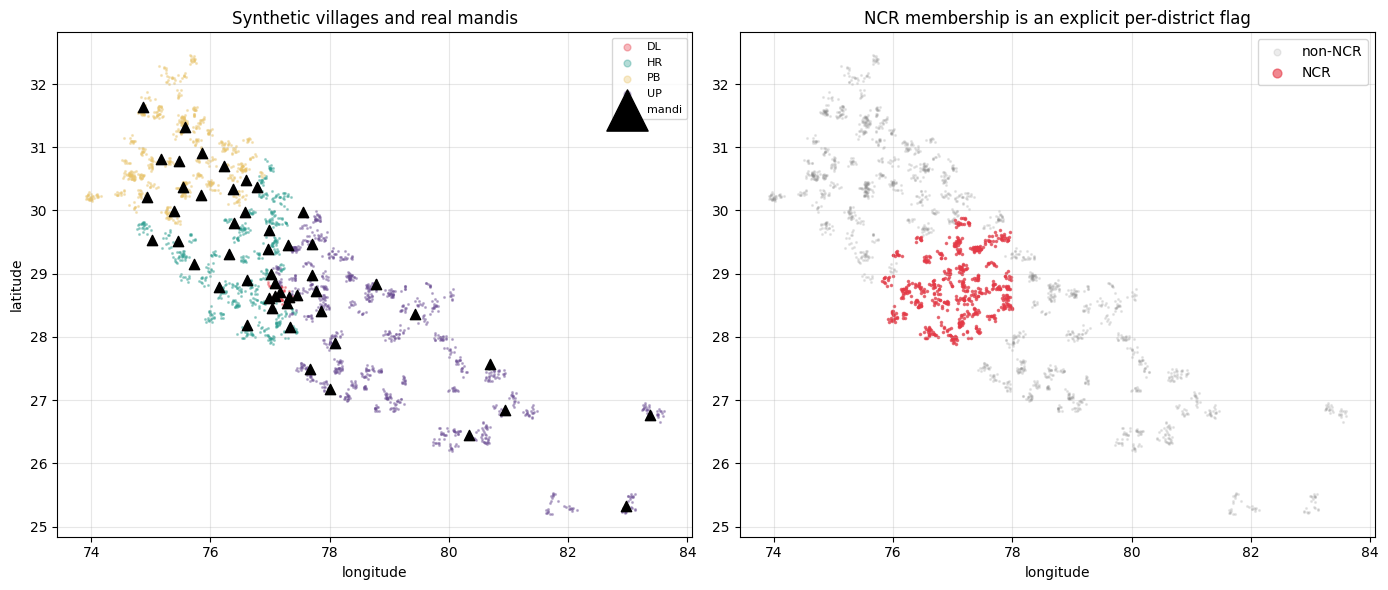

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = {"DL":"#e63946","HR":"#2a9d8f","PB":"#e9c46a","UP":"#6a4c93"}

ax = axes[0]
for sc, g in villages.groupby("state_code"):
    ax.scatter(g.longitude, g.latitude, s=1.5, alpha=0.35, c=colors[sc], label=sc)
ax.scatter(mandi_locs.longitude, mandi_locs.latitude, s=55, c="black",
           marker="^", label="mandi", zorder=5)
ax.set(title="Synthetic villages and real mandis", xlabel="longitude", ylabel="latitude")
ax.legend(markerscale=4, fontsize=8)

ax = axes[1]
ncr_v = villages[villages.in_ncr]
ax.scatter(villages.longitude, villages.latitude, s=1.5, alpha=0.15, c="grey", label="non-NCR")
ax.scatter(ncr_v.longitude, ncr_v.latitude, s=2.5, alpha=0.6, c="#e63946", label="NCR")
ax.set(title="NCR membership is an explicit per-district flag", xlabel="longitude")
ax.legend(markerscale=4)
plt.tight_layout(); plt.show()

## 5. Synthetic shops on a demand surface

There is no authoritative registry of rural building-material dealers, so shops are
fully synthetic. They are **not** scattered uniformly over district polygons — that
would put cement dealers in the middle of fields. Placement is conditioned on a
demand surface combining urbanisation and market-town gravity, then offset to the
settlement edge where an approach road would be.

900 synthetic shops


,shop_id,shop_category,capacity_tonnes,daily_demand_kg,vehicle_access,road_access_quality,is_synthetic,generation_method
0,SHP_1EAA5B6C57A6,sanitary,20.9,595.0,2-axle,0.599,True,demand_surface_anchored_v1
1,SHP_0BD01455FD97,paint,28.9,1030.0,LCV,0.431,True,demand_surface_anchored_v1
2,SHP_AD88E2370BB3,hardware,56.6,2400.0,2-axle,0.542,True,demand_surface_anchored_v1
3,SHP_E04F4D83B324,sanitary,27.5,1200.0,LCV,0.324,True,demand_surface_anchored_v1
4,SHP_00B2B9AD9523,cement,180.3,6355.0,3-axle,0.894,True,demand_surface_anchored_v1


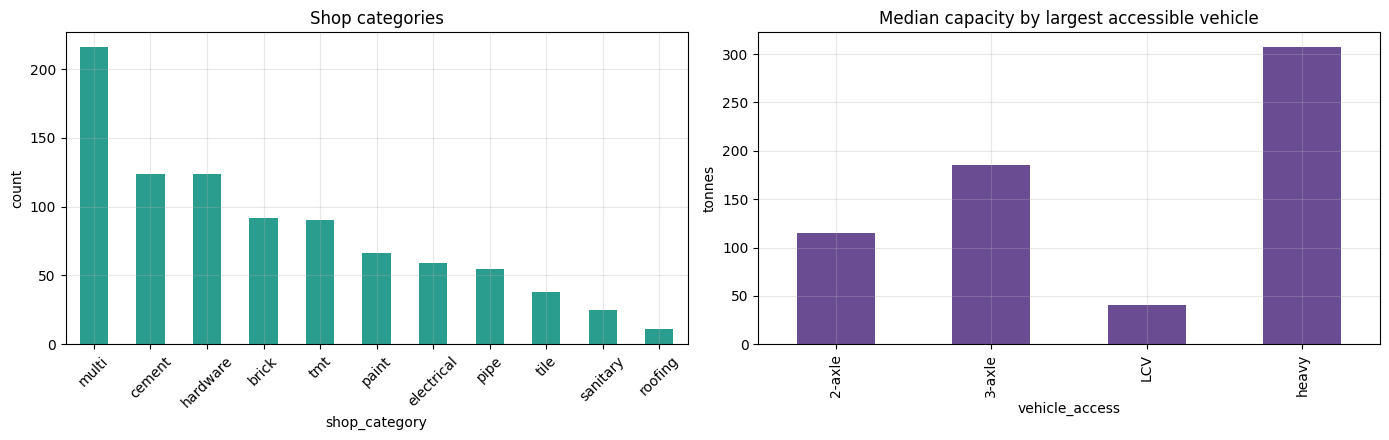

In [9]:
from vb.generate.shops import build_shops
shop_locs, shops = build_shops(cfg, villages)
print(f"{len(shops)} synthetic shops")
display(shops[["shop_id","shop_category","capacity_tonnes","daily_demand_kg",
               "vehicle_access","road_access_quality","is_synthetic",
               "generation_method"]].head())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
shops.shop_category.value_counts().plot.bar(ax=axes[0], color="#2a9d8f")
axes[0].set(title="Shop categories", ylabel="count")
axes[0].tick_params(axis="x", rotation=45)
shops.groupby("vehicle_access").capacity_tonnes.median().plot.bar(ax=axes[1], color="#6a4c93")
axes[1].set(title="Median capacity by largest accessible vehicle", ylabel="tonnes")
plt.tight_layout(); plt.show()

## 6. Farmer nodes — a privacy design decision

A farmer node is a **pickup point, not a person and not a home**. Nodes are snapped to
an agricultural envelope — a ring 0.4–3.5 km *outside* the settlement core — so no row
resembles a residential address. There are no names, phone numbers or household
identifiers in this table, and none should ever be added.

1400 farmer logistics nodes


,farmer_node_id,district,farm_size_ha,primary_crop_key,secondary_crop_key,road_access_km,generation_method
0,FRM_B05D4D9F0585,Gurdaspur,1.82,tomato,<NA>,0.469,agri_envelope_ring_v1
1,FRM_ED26D3777638,Barnala,2.65,gram,potato,0.826,agri_envelope_ring_v1
2,FRM_CE4E12252703,Muktsar,6.49,gram,maize,0.783,agri_envelope_ring_v1
3,FRM_285C67C19A11,Nawanshahr,3.15,cotton,<NA>,0.478,agri_envelope_ring_v1
4,FRM_40009B2616D3,Hapur,1.25,urad,<NA>,1.064,agri_envelope_ring_v1


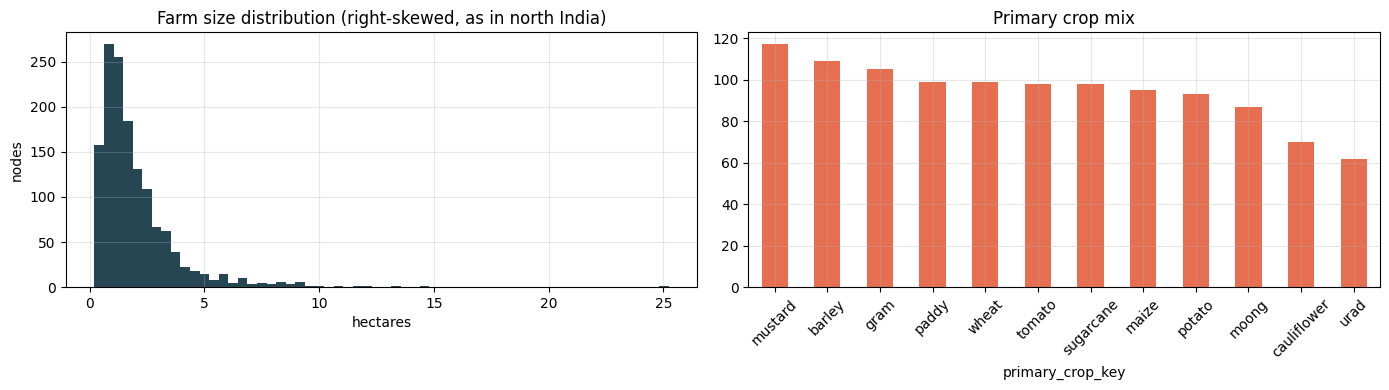

In [10]:
from vb.generate.farmers import build_farmer_nodes
farmers = build_farmer_nodes(cfg, villages, mandi_locs)
print(f"{len(farmers)} farmer logistics nodes")
display(farmers[["farmer_node_id","district","farm_size_ha","primary_crop_key",
                 "secondary_crop_key","road_access_km","generation_method"]].head())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(farmers.farm_size_ha, bins=60, color="#264653")
axes[0].set(title="Farm size distribution (right-skewed, as in north India)",
            xlabel="hectares", ylabel="nodes")
farmers.primary_crop_key.value_counts().head(12).plot.bar(ax=axes[1], color="#e76f51")
axes[1].set(title="Primary crop mix"); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 7. Fleet generation with physical coherence

Vehicle attributes are drawn from a table of coherent classes rather than sampled
independently — independent sampling produces nonsense like a 30-tonne electric pickup
returning 14 km/l. The schema actively rejects such rows.

In [11]:
from vb.generate.trucks import build_trucks, build_truck_availability
trucks = build_trucks(cfg, depots)
availability = build_truck_availability(cfg, trucks)
print(f"{len(trucks)} trucks, {len(availability)} availability slots")

display(trucks.groupby("vehicle_class").agg(
    n=("truck_id","count"),
    median_capacity_kg=("capacity_kg","median"),
    median_kmpl=("avg_kmpl","median"),
    median_range_km=("max_route_km","median"),
).round(1))

print("\nPhysical coherence checks:")
print("  heavy trucks (>12t) with light-vehicle economy (>7 kmpl):",
      ((trucks.capacity_kg > 12000) & (trucks.avg_kmpl > 7)).sum(), "(must be 0)")
print("  EVs above 5t capacity:",
      ((trucks.fuel_type == "ev") & (trucks.capacity_kg > 5000)).sum(), "(must be 0)")

600 trucks, 1222 availability slots


,n,median_capacity_kg,median_kmpl,median_range_km
vehicle_class,,,,
2axle,161,8560.0,5.4,320.0
3axle,112,15065.0,4.1,440.0
LCV,179,2740.0,10.1,190.0
multi_axle,41,25970.0,3.2,630.0
pickup,107,1160.0,13.1,120.0



Physical coherence checks:
  heavy trucks (>12t) with light-vehicle economy (>7 kmpl): 0 (must be 0)
  EVs above 5t capacity: 0 (must be 0)


## 8. Hindi / English / Hinglish request corpus

The corpus must teach a parser to survive real input: code-switching mid-sentence,
Devanagari digits, ASR phonetic confusions, and missing fields.

Two design rules make it trainable rather than merely large:

- **Labels stay canonical.** However corrupted the surface form, the label is always
  the crop key, mandi key, numeric value and unit enum.
- **Every utterance carries its template family**, so splits can hold out whole
  paraphrase families and measure generalisation instead of memorisation.

Noise is *modelled*, not sprinkled: substitutions follow phonetic neighbours
(स/श, b/v, aa/a) because that is the error distribution a voice interface produces.

In [12]:
from vb.generate.requests import build_transport_requests
requests = build_transport_requests(cfg, farmers, shops, mandi_locs, shop_locs, trucks)
print(f"{len(requests)} requests")

sample = requests[requests.raw_utterance.notna()].sample(16, random_state=5)
for _, r in sample.iterrows():
    lab = f"{r.label_crop_key},{r.label_mandi_key},{r.label_quantity_value},{r.label_quantity_unit}"
    print(f"[{r.input_language:8s}|{r.input_mode:5s}] {r.raw_utterance!r}")
    print(f"{'':20s}-> {lab}   (conf c={r.parsed_crop_conf} m={r.parsed_mandi_conf})")

18000 requests
[hinglish|text ] 'brick restock 600.0 bori for Ganpati Bricks & Blocks'
                    -> None,None,600.0,bori   (conf c=0.0 m=0.0)
[en      |text ] 'to बरनाला: mustard, 14.1 kuntal'
                    -> mustard,barnala,14.1,quintal   (conf c=0.95 m=0.95)
[hi      |voice] 'गाड़ी भेजो shaharanpur गेहूं 25 बोरा'
                    -> wheat,saharanpur,25.0,bori   (conf c=0.633 m=0.668)
[hinglish|text ] 'pipe restock 26.93 tonne for Deep Pipes & Fittings'
                    -> None,None,26.93,tonne   (conf c=0.0 m=0.0)
[hi      |voice] '16 बोरे धान kurukshetra mandi भेजना है'
                    -> paddy,kurukshetra,16.0,bori   (conf c=0.95 m=0.95)
[en      |text ] 'need vehicle saharanpur paddi 21.6 qtl'
                    -> paddy,saharanpur,21.6,quintal   (conf c=0.95 m=0.95)
[hinglish|text ] 'cement restock 30.0 tonne for Sharma Cement Store'
                    -> None,None,30.0,tonne   (conf c=0.0 m=0.0)
[en      |text ] 'mong kaithal three bori'
            

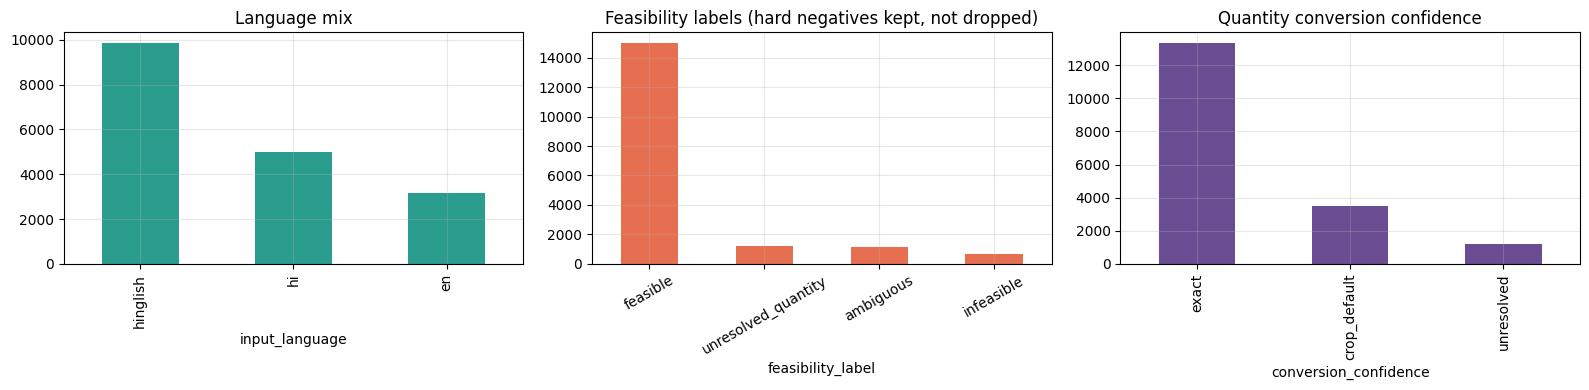

1208 requests (6.7%) have an UNRESOLVED quantity.
Their quantity_kg is null: True


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
requests.input_language.value_counts().plot.bar(ax=axes[0], color="#2a9d8f")
axes[0].set(title="Language mix")
requests.feasibility_label.value_counts().plot.bar(ax=axes[1], color="#e76f51")
axes[1].set(title="Feasibility labels (hard negatives kept, not dropped)")
axes[1].tick_params(axis="x", rotation=30)
requests.conversion_confidence.value_counts().plot.bar(ax=axes[2], color="#6a4c93")
axes[2].set(title="Quantity conversion confidence")
plt.tight_layout(); plt.show()

n_unres = (requests.conversion_confidence == "unresolved").sum()
print(f"{n_unres} requests ({n_unres/len(requests):.1%}) have an UNRESOLVED quantity.")
print("Their quantity_kg is null:", requests[requests.conversion_confidence=='unresolved'].quantity_kg.isna().all())

## 9. Route graph and time-dependent scenarios

Two rules the graph enforces:

- **Edges are directed.** A→B and B→A are separate rows with separate IDs, because
  one-ways, gradients and congestion are asymmetric.
- **Scenarios never overwrite the baseline.** Each scenario is a distinct set of rows
  keyed by `scenario_id`, so a solution can always be traced to the exact cost snapshot
  it was computed against.

Straight-line distance is **not** used as road distance. A length-dependent detour
factor produces the offline estimate, and haversine is retained separately as a QA
lower bound.

In [14]:
from vb.generate.graph import build_route_edges, build_scenarios_table, SCENARIOS

locations_master = pd.concat([villages, depots, mandi_locs, shop_locs], ignore_index=True)
print(f"locations_master: {len(locations_master)} rows")
display(locations_master.location_type.value_counts().to_frame("count"))

edges = build_route_edges(cfg, locations_master)
scenarios = build_scenarios_table(cfg)
print(f"\nroute_edges: {len(edges)} rows across {edges.scenario_id.nunique()} scenarios")
display(scenarios[["scenario_id","name","traffic_factor","risk_factor","is_baseline"]])

locations_master: 3442 rows


,count
location_type,
village,2400
shop,900
depot,92
mandi,50



route_edges: 375968 rows across 8 scenarios


,scenario_id,name,traffic_factor,risk_factor,is_baseline
0,SCN_BASELINE,baseline,1.00,1.00,True
1,SCN_MORNING_PEAK,morning_peak,1.45,1.10,False
2,SCN_MIDDAY,midday,1.12,1.00,False
3,SCN_EVENING_PEAK,evening_peak,1.52,1.14,False
4,SCN_NIGHT,night,0.88,1.25,False
5,SCN_WEEKEND,weekend,1.05,1.00,False
6,SCN_HARVEST_PEAK,harvest_peak,1.38,1.08,False
7,SCN_MONSOON_RAIN,monsoon_rain,1.34,1.60,False


Road distance vs great-circle (detour factor):
count    46996.000
mean         1.364
std          0.578
min          1.074
25%          1.266
50%          1.370
75%          1.410
max         15.000
dtype: float64

Edges shorter than the geodesic (must be 0): 0


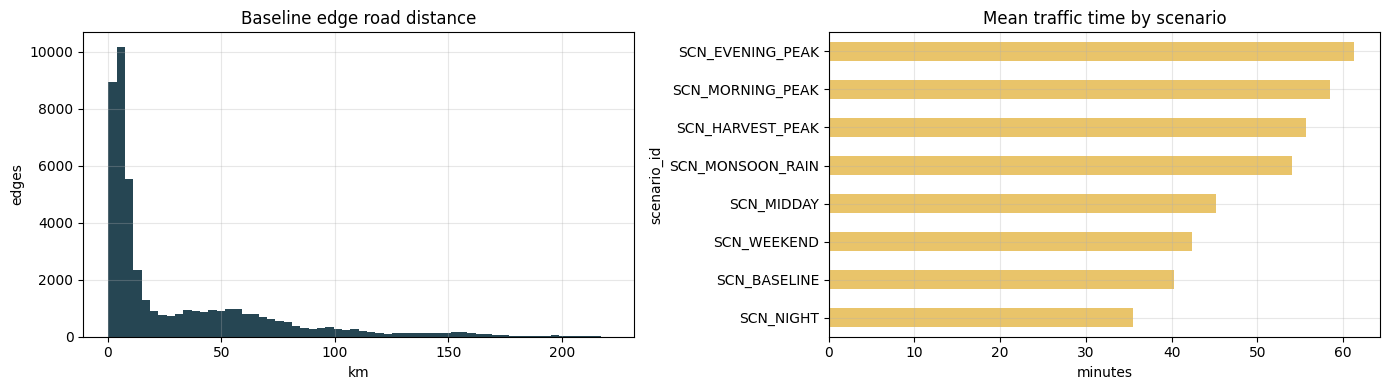

In [15]:
base = edges[edges.scenario_id == "SCN_BASELINE"]
print("Road distance vs great-circle (detour factor):")
print((base.distance_km / base.haversine_km.clip(lower=0.01)).describe().round(3))
print("\nEdges shorter than the geodesic (must be 0):",
      (base.distance_km < base.haversine_km * 0.98).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(base.distance_km, bins=60, color="#264653")
axes[0].set(title="Baseline edge road distance", xlabel="km", ylabel="edges")
edges.groupby("scenario_id").traffic_time_min.mean().sort_values().plot.barh(
    ax=axes[1], color="#e9c46a")
axes[1].set(title="Mean traffic time by scenario", xlabel="minutes")
plt.tight_layout(); plt.show()

## 10. Canonical optimization instances

An **instance** is the solver-agnostic statement of one routing problem, pinned to one
`cost_snapshot_id`. This is the contract that makes classical/quantum comparison honest:
every solver consumes the same instance and the same cost matrix, and nothing re-derives
its own distances.

Instances are sized in bands. The `quantum` band is deliberately tiny — a permutation
QUBO needs (n+1)² qubits, so 3 customers is 16 qubits and 6 would be 49, which is beyond
any statevector simulator.

In [16]:
from vb.generate.instances import build_route_instances, DEFAULT_OBJECTIVE_WEIGHTS
instances, instance_requests = build_route_instances(
    cfg, requests, trucks, locations_master, depots)
print(f"{len(instances)} instances, {len(instance_requests)} memberships")
display(instances.groupby(["size_band","problem_type"]).size().unstack(fill_value=0))
print("\nObjective weights (stored in data, not hard-coded in solvers):")
print(json.dumps(DEFAULT_OBJECTIVE_WEIGHTS, indent=2))
print(f"\ncapacity-feasible: {instances.capacity_feasible.sum()}/{len(instances)}")
print(f"quantum-ready: {instances.quantum_ready.sum()}")
print("max qubits among quantum-ready:",
      instances[instances.quantum_ready].estimated_qubits_permutation.max())

2000 instances, 37101 memberships


problem_type,CIRCULAR_VRP,CVRP,PDP,TSP,VRPTW
size_band,,,,,
large,84,37,95,0,58
medium,192,111,250,0,165
quantum,50,18,57,47,28
small,235,116,296,0,161



Objective weights (stored in data, not hard-coded in solvers):
{
  "distance_km": 1.0,
  "time_min": 0.35,
  "fuel_inr": 0.01,
  "toll_inr": 0.01,
  "risk": 12.0,
  "empty_km": 0.85,
  "circular_bonus": -1.1
}

capacity-feasible: 1955/2000
quantum-ready: 47
max qubits among quantum-ready: 16


## 11. Leakage-safe train / validation / test splits

Random row splitting is wrong here in four independent ways, and each gets its own defence:

| Leak | Defence |
|---|---|
| Geographic — neighbouring villages share corridors and mandi catchments | whole districts held out |
| Temporal — requests carry seasonal structure | date cutoff held out |
| Template — a test sentence that paraphrases a training one measures memorisation | whole template families held out |
| Structural — two instances with the same hash are the same problem | split keyed on `instance_hash` |

A fifth subtlety: because the district and time rules can pull one instance of a
repeated utterance into test, any utterance appearing in test anywhere is promoted to
test everywhere.

In [17]:
from vb.splits import split_requests, split_instances, check_leakage
requests = split_requests(requests, cfg.holdout_districts, cfg.holdout_time_from)
instances = split_instances(instances, cfg.holdout_districts)

display(pd.crosstab(requests.split, requests.split_reason))
print("\nsplit proportions:")
print(requests.split.value_counts(normalize=True).round(3))

report = check_leakage(requests, instances, cfg.holdout_districts)
print("\nLEAKAGE REPORT")
for k, v in report.items():
    print(f"  {k}: {v}")
assert report["passed"], "leakage check failed"
print("\nAll leakage checks PASS")

split_reason,duplicate_of_test_utterance,holdout_district,holdout_template_family,holdout_time,random_bucket
split,,,,,
test,1435,808,1954,1131,1415
train,0,0,0,0,9751
validation,0,0,0,0,1506



split proportions:
split
train         0.542
test          0.375
validation    0.084
Name: proportion, dtype: float64

LEAKAGE REPORT
  request_id_overlap: 0
  holdout_families_leaked_into_train: []
  holdout_districts_leaked_into_train: []
  holdout_districts_in_train_instances: []
  instance_hash_overlap: 0
  duplicate_utterances_across_split: 0
  passed: True

All leakage checks PASS


## 12. Export and reproducibility metadata

In [18]:
from vb.io import write_table
from vb import config as C
C.ensure_dirs(); cfg.save()

exports = [
    (locations_master, C.MASTER/"locations_master.csv", "mixed"),
    (mandis, C.MASTER/"mandis.csv", "mixed"),
    (mandi_commodities, C.MASTER/"mandi_commodities.csv", "mixed"),
    (crops, C.MASTER/"crops.csv", "verified"),
    (scenarios, C.MASTER/"scenarios.csv", "synthetic"),
    (shops, C.SYNTHETIC/"shops.csv", "synthetic"),
    (farmers, C.SYNTHETIC/"farmer_nodes.csv", "synthetic"),
    (trucks, C.SYNTHETIC/"trucks.csv", "synthetic"),
    (availability, C.SYNTHETIC/"truck_availability.csv", "synthetic"),
    (requests, C.SYNTHETIC/"transport_requests.csv", "synthetic"),
    (edges, C.SYNTHETIC/"route_edges.csv", "synthetic"),
    (instances, C.SYNTHETIC/"route_instances.csv", "synthetic"),
    (instance_requests, C.SYNTHETIC/"instance_requests.csv", "synthetic"),
]
summary = []
for df, path, prov in exports:
    entry = write_table(df, path, cfg, description=path.stem,
                        provenance=prov, overwrite=True)
    summary.append({"table": entry["table"], "rows": entry["rows"],
                    "cols": entry["n_columns"], "provenance": prov,
                    "sha256": entry["file_sha256"][:16]})
display(pd.DataFrame(summary))
print(f"\nseed={cfg.seed}  config_hash={cfg.config_hash()}  version={cfg.dataset_version}")

,table,rows,cols,provenance,sha256
0,locations_master,3442,23,mixed,a89b10a38d0f433b
1,mandis,50,15,mixed,f05f2b577475ba4a
2,mandi_commodities,383,4,mixed,d22a45fdb88f5325
3,crops,18,12,verified,5708799f834dd9c2
4,scenarios,8,7,synthetic,2160cb702e033966
5,shops,900,14,synthetic,6c02a3a59135948c
6,farmer_nodes,1400,17,synthetic,a6604410dd492c2f
7,trucks,600,19,synthetic,15e70ef4eb8c1f53
8,truck_availability,1222,9,synthetic,0c6c4f18103d0ad9
9,transport_requests,18000,40,synthetic,9cc8b60a223e9745



seed=20260903  config_hash=f7cef15e36427d07  version=v0.1


## 13. Validation and QA

In [19]:
from vb.run_qa import run as run_qa
results = run_qa()
print()
print("schema results:")
for name, r in results["schemas"].items():
    print(f"  {name:24s} {'PASS' if r['passed'] else 'FAIL'}")
print(f"\ngeospatial : {results['geospatial']['passed']}")
print(f"referential: {results['referential']['passed']}")
print(f"statistical: {results['statistical']['passed']}")
print(f"leakage    : {results['leakage']['passed']}")
print(f"\nOVERALL: {'PASS' if results['all_passed'] else 'FAIL'}")

INFO === schema validation ===


INFO   locations_master       PASS


INFO   mandis                 PASS


INFO   shops                  PASS


INFO   farmer_nodes           PASS


...

INFO   passed=True


INFO === leakage QA ===


INFO   passed=True


INFO === OVERALL: PASS ===



schema results:
  locations_master         PASS
  mandis                   PASS
  shops                    PASS
  farmer_nodes             PASS
  trucks                   PASS
  transport_requests       PASS
  route_edges              PASS
  route_instances          PASS

geospatial : True
referential: True
statistical: True
leakage    : True

OVERALL: PASS


In [20]:
geo = results["geospatial"]
print("Geospatial QA detail:")
for k in ["n_locations","n_outside_coarse_bbox","n_outside_district_envelope",
          "n_duplicate_coordinates","n_ncr_flag_mismatches","n_edges",
          "n_edges_shorter_than_geodesic","n_self_loop_edges",
          "mean_abs_direction_asymmetry_km"]:
    if k in geo:
        print(f"  {k}: {geo[k]}")
print(f"\ncontainment method: {geo['containment_method']}")
print(f"KNOWN LIMITATION: {geo['containment_limitation']}")

Geospatial QA detail:
  n_locations: 3442
  n_outside_coarse_bbox: 0
  n_outside_district_envelope: 7
  n_duplicate_coordinates: 80
  n_ncr_flag_mismatches: 0
  n_edges: 375968
  n_edges_shorter_than_geodesic: 0
  n_self_loop_edges: 0
  mean_abs_direction_asymmetry_km: 0.9696

containment method: circular_district_envelope
KNOWN LIMITATION: No boundary polygons available in the routing research. A point just across a real district border will not be detected. the application must use LGD polygons.


## 14. Summary and known limitations

### What this pipeline produces

A reproducible prototype dataset — ~3.4k locations, 18k requests, 2k optimization
instances, 376k directed edges across 8 traffic scenarios — that passes schema,
geospatial, referential, statistical and leakage validation, and serves as the common
input to NLU parsing, truck matching, circular logistics, and classical *and* quantum
route optimization.

### Real limitations, stated plainly

1. **No official administrative data.** The LGD/Census directory was not acquired, so
   district codes are internal (`VB-` prefixed) and subdistrict/village/pincode codes are
   null. This is deliberate: fabricating official codes would be worse than empty fields.
2. **Mandi coordinates are town-level.** Real names, approximate positions,
   `coordinate_verified = False` throughout. Not reconciled against e-NAM or state APMC
   portals — and e-NAM would not be sufficient anyway, since it covers only integrated
   markets, not the full universe of physical mandis.
3. **Containment QA uses circular envelopes, not polygons.** A point just across a real
   district border will not be detected.
4. **Road costs are an offline detour model**, not measured routing. Directionally
   asymmetric and geodesically bounded, but not survey-accurate.
5. **Everything except mandi and district names is synthetic.** No distributional claim
   about real rural logistics is supported by this data. It is fit for building and
   testing the pipeline; it is not evidence about the world.